In [2]:
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
roc_auc_score,
RocCurveDisplay,
)
import joblib

In [3]:
random_state = 42
np.random.seed(random_state)
random.seed(random_state)

## Rozpakowanie i przygotowanie danych


In [4]:
#tu używamy Path - biblioteki do pracy z systemem plików i folderami

#folder z calym data setem znajduje się tu
DATA_DIR = Path(r"C:\Users\user\Desktop\brain_tumor\data\brain_tumor_mri_dataset")
#tworzymy sciezke do danych treningowych i testowych
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"
#sprawdzamy czy foldery istnieją i co się w nich znajduje 
print(TRAIN_DIR.exists(), TEST_DIR.exists())
print(list(TRAIN_DIR.iterdir()))


True True
[WindowsPath('C:/Users/user/Desktop/brain_tumor/data/brain_tumor_mri_dataset/Training/glioma'), WindowsPath('C:/Users/user/Desktop/brain_tumor/data/brain_tumor_mri_dataset/Training/meningioma'), WindowsPath('C:/Users/user/Desktop/brain_tumor/data/brain_tumor_mri_dataset/Training/notumor'), WindowsPath('C:/Users/user/Desktop/brain_tumor/data/brain_tumor_mri_dataset/Training/pituitary')]


In [5]:
#dataFrame 
TUMOR_CLASSES = ["glioma_tumor", "meningioma_tumor", "notumor", "pituitary_tumor"]
NO_TUMOR_CLASS = "notumor"

VALID_IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png",] 

def binary_label(orginal_label: str) -> int:
    if orginal_label == NO_TUMOR_CLASS:
        return 0
    else:        return 1
    
#

## Funkcja budujaca DataFrame

In [6]:
# funkcja do budowania DataFrame z danymi, która iteruje po folderach z klasami,
#  a następnie po plikach w tych folderach, sprawdza czy plik jest obrazem i dodaje informacje o ścieżce do obrazu,
#  oryginalnej etykiecie, binarnej etykiecie (0 lub 1) oraz nazwie binarnej etykiety do listy danych, a następnie tworzy DataFrame z tej listy
def build_dataframe(split_dir: Path) -> pd.DataFrame:
    data = []  #pusta lsta do której bedziemy dodawać dane
    for class_dir in split_dir.iterdir(): #iterujemy po folderach z klasami
        if not class_dir.is_dir(): #sprawdzamy czy to jest folder
            continue
        orginal_label = class_dir.name #nazwa folderu to nasza etykieta
        
        if orginal_label == "notumor":
            binary_label_value = 0
            binary_label_name = "no_tumor"
        else:
            binary_label_value = 1
            binary_label_name = "tumor"

        for image_path in class_dir.iterdir(): #iterujemy po plikach w folderze
            if image_path.suffix.lower() not in VALID_IMAGE_EXTENSIONS: #sprawdzamy czy to jest obraz SUFFIX - rozszerzenie pliku
                continue
            data.append(
                {
                    "image_path": image_path,
                    "original_label": orginal_label,
                    "binary_label_value": binary_label_value,
                    "binary_label_name": binary_label_name,
                }
            )
    return pd.DataFrame(data) #tworzymy DataFrame z listy danych

full_train_df = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)
display(full_train_df.head(20))
display(full_train_df["binary_label_name"].value_counts())
display(test_df["binary_label_name"].value_counts())


,image_path,original_label,binary_label_value,binary_label_name
0,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
1,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
2,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
3,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
4,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
5,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
6,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
7,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
8,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor
9,C:\Users\user\Desktop\brain_tumor\data\brain_t...,glioma,1,tumor


binary_label_name
tumor       4200
no_tumor    1400
Name: count, dtype: int64

binary_label_name
tumor       1200
no_tumor     400
Name: count, dtype: int64

## Train/validation split


In [8]:
#from sklearn.model_selection import train_test_split - ta funcja sluzy do podziału danych na zbiór treningowy i walidacyjny
# mimo ze nazywa się train test to my tylko dzielimy na train validation, test zostawiamy na koniec do ostatecznej ewaluacji modelu
train_df, val_df = train_test_split(full_train_df, test_size=0.2, stratify=full_train_df["binary_label_value"], random_state=random_state)
# test_size - to jest parametr który określa jaki procent danych ma trafić do zbioru walidacyjnego(w tym przypadku 20%)
# stratify - to jest parametr który pozwala nam zachować proporcje klas w obu zbiorach, czyli w train i validation bedziemy mieli podobna liczbe przypadków z każda klasą
#obie czesci maja podbny rozklad klas, co jest ważne dla trenowania modelu

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

print("\nTrain set distribution:")
print(train_df["binary_label_name"].value_counts())
print("\nValidation set distribution:")
print(val_df["binary_label_name"].value_counts())
print("\nTest set distribution:")
print(test_df["binary_label_name"].value_counts())

train_df shape: (4480, 4)
val_df shape: (1120, 4)
test_df shape: (1600, 4)

Train set distribution:
binary_label_name
tumor       3360
no_tumor    1120
Name: count, dtype: int64

Validation set distribution:
binary_label_name
tumor       840
no_tumor    280
Name: count, dtype: int64

Test set distribution:
binary_label_name
tumor       1200
no_tumor     400
Name: count, dtype: int64


## Liczba obrazów w klasach w zbiorze treningowym, walidacyjnym i testowym

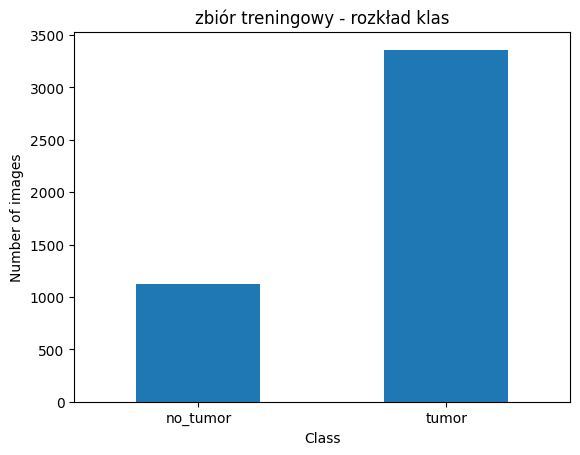

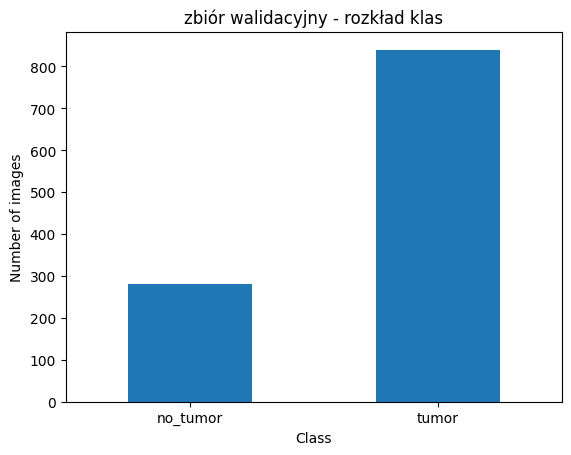

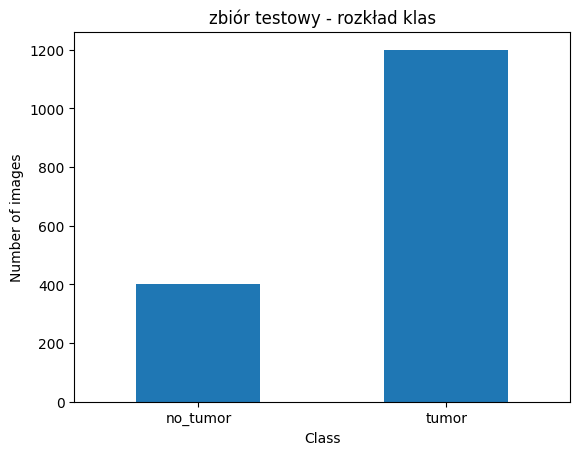

In [9]:
def plot_class_distribution(df: pd.DataFrame, title: str):
    counts = df["binary_label_name"].value_counts().sort_index() #sort_index - sortuje indeksy, czyli klasy, w porządku alfabetycznym, dzięki temu wykres będzie bardziej czytelny
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    plt.xticks(rotation=0)  #ustawia etykiety klas na osi x poziomo
    plt.show()
plot_class_distribution(train_df, "zbiór treningowy - rozkład klas")
plot_class_distribution(val_df, "zbiór walidacyjny - rozkład klas")
plot_class_distribution(test_df, "zbiór testowy - rozkład klas")


## Przykladowe obrazy

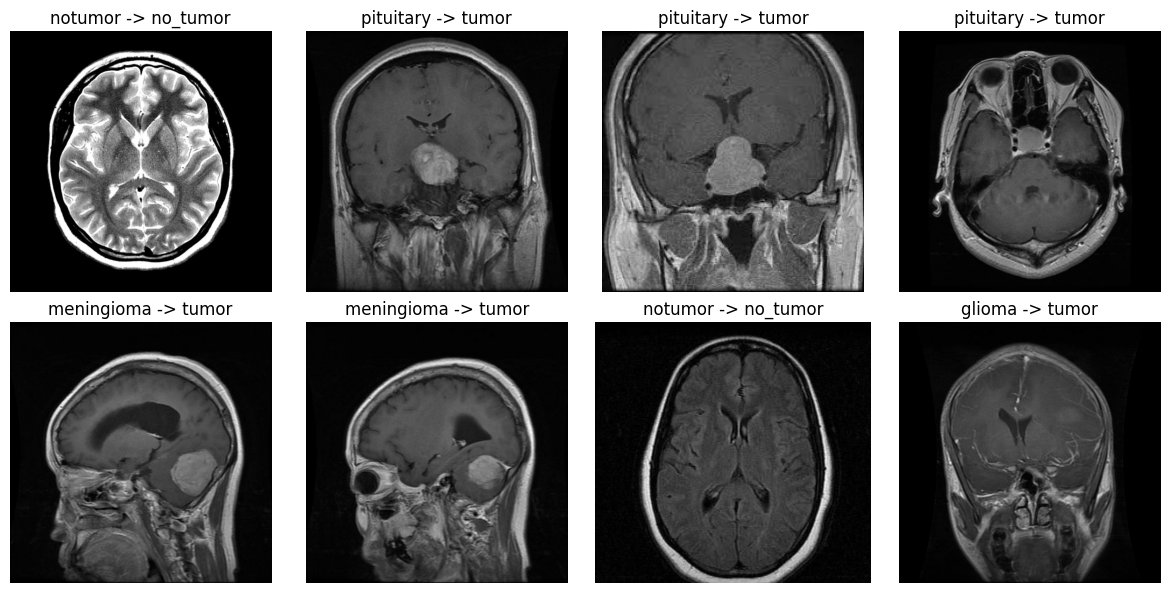

In [10]:
#funkcja do wyświetlania losowych obrazów z DataFrame
def show_random_images(df: pd.DataFrame, n: int = 8):
    sample = df.sample(n=n, random_state=random_state) #losujemy n obrazów z DataFrame

    plt.figure(figsize=(12, 6)) #ustawiamy rozmiar wykresu
    for i, (_, row) in enumerate(sample.iterrows(), start=1): #iterujemy po wylosowanych obrazach, iterrows() zwraca indeks i wiersz, ale my nie potrzebujemy indeksu, więc używamy _ jako zmiennej do ignorowania
        image = imread(row["image_path"]) 

        plt.subplot(2, 4, i)
        plt.imshow(image, cmap="gray")
        plt.title(f"{row['original_label']} -> {row['binary_label_name']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_random_images(train_df, n=8)


## Sprawdzenie rozmiarów obrazów

In [11]:
#sprawdzamy rozmiary obrazów w zbiorze treningowym, modele potrzebują obrazów o jednakowym rozmiarze, więc musimy wiedzieć jakie są rozmiary naszych obrazów, żeby potem je odpowiednio przeskalować
def get_image_shape(path: str):
    qimage = imread(path) #wczytujemy obraz z podanej ścieżki qimage - to jest zmienna, która przechowuje wczytany obraz jako tablicę numpy
    return qimage.shape #qimage.shape - to jest atrybut tablicy numpy, który zwraca krotkę z wymiarami obrazu (wysokość, szerokość, liczba kanałów)

sample_shapes = train_df.sample(200, random_state=random_state)["image_path"].apply(get_image_shape) #losujemy 200 obrazów z train_df, bierzemy ich ścieżki i stosujemy funkcję get_image_shape do każdej ścieżki, dzięki temu dostajemy serię z kształtami obrazów
shape_counts = sample_shapes.value_counts().head(10) #value_counts() - liczy ile razy występuje każdy unikalny kształt, head(10) - bierzemy tylko 10 najczęstszych kształtów
print(shape_counts)

image_path
(512, 512)       81
(512, 512, 3)    63
(225, 225, 3)     8
(442, 442, 3)     3
(236, 236, 3)     3
(630, 630, 3)     3
(251, 201, 3)     3
(242, 208, 3)     3
(630, 630)        2
(444, 468, 3)     2
Name: count, dtype: int64


## Preprocessing obrazu

(128, 128) 7.804313e-12 0.787501


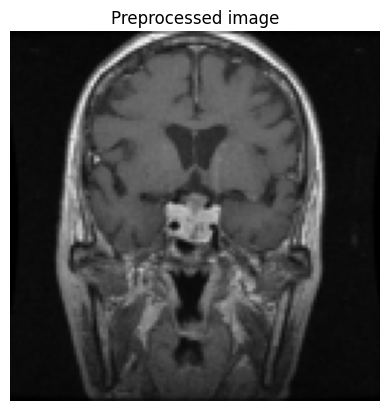

In [12]:
#funkcja do ładowania i przetwarzania obrazu, która wczytuje obraz z podanej ścieżki, konwertuje go na skalę szarości (jeśli jest kolorowy),
#zmienia jego rozmiar na 128x128 i zwraca jako tablicę numpy z wartościami typu float32 w zakresie [0, 1]
IMAGE_SIZE = (128, 128)

def load_and_preprocess_image(path: str, image_size=IMAGE_SIZE) -> np.ndarray:
    """Load image, convert to grayscale, resize and return float array.""" 
    image = imread(path)

    # tutaj sprawdzamy czy obraz jest kolorowy (3 wymiary - wysokosc, szerokosc, liczba kanałów), 
    # jeśli tak to konwertujemy go na skale szarości
    if image.ndim == 3:  #sprawdzamy czy obraz jest kolorowy (3 wymiary - wysokosc, szerokosc, liczba kanałów) #ndim zwraca liczbę wymiarów
        if image.shape[-1] == 4: #sprawdzamy czy obraz ma 4 kanały (np. RGBA), jeśli tak to bierzemy tylko pierwsze 3 kanały (RGB), bo alpha nie jest nam potrzebna
            image = image[..., :3] #bierzemy tylko pierwsze 3 kanały (RGB), bo alpha nie jest nam potrzebna
        image = rgb2gray(image)  #rgb2gray - ta funkcja konwertuje obraz RGB na skale szarości


    

    image_resized = resize( #zwraca nam obraz jako tablicę numpy z wartościami w zakresie [0, 1], bo resize z preserve_range=False normalizuje wartości do tego zakresu
        image,
        image_size,
        anti_aliasing=True,
        preserve_range=False,
    )
    return image_resized.astype(np.float32) #zwracamy obraz jako tablicę numpy z wartościami typu float32

example_path = train_df.iloc[0]["image_path"] #iloc[0] - bierzemy pierwszy wiersz z train_df, ["image_path"] - bierzemy wartość z kolumny "image_path", czyli ścieżkę do obrazu #iloc - to jest metoda DataFrame, która pozwala nam wybrać wiersz po indeksie
example_image = load_and_preprocess_image(example_path) #ładujemy i przetwarzamy obraz z tej ścieżki, dzięki temu dostajemy przetworzony obraz jako tablicę numpy
print(example_image.shape, example_image.min(), example_image.max()) #sprawdzamy kształt obrazu i zakres wartości, powinien być (128, 128) i wartości w zakresie [0, 1]

plt.imshow(example_image, cmap="gray")
plt.title("Preprocessed image")
plt.axis("off")
plt.show()

## Reprezentacja obrazu jako liczby

In [13]:
#wyciągamy surowe piksele z obrazu, czyli spłaszczzamy obraz do jednowymiarowej tablicy,
#  która będzie zawierać wartości pikseli, dzięki temu będziemy mogli użyć tych wartości jako cech do trenowania modelu
def extract_raw_pixels(path: str) -> np.ndarray:
    image = load_and_preprocess_image(path)
    return image.ravel() #ravel() - spłaszcza tablicę do jednowymiarowej, czyli z (128, 128) robi (16384,), gdzie 16384 to liczba pikseli w obrazie 128x128

raw_features = extract_raw_pixels(example_path)
print(raw_features.shape)


(16384,)


# HOG (Histogram of Oriented Gradients)

HOG (Histogram of Oriented Gradients) to metoda ekstrakcji cech z obrazów wykorzystywana do wykrywania obiektów, takich jak ludzie czy pojazdy. Opiera się na analizie kierunków krawędzi występujących w obrazie.

## Jak działa?

## Obliczanie HOG

1. Dla każdego piksela obliczane są gradienty w kierunku poziomym ($G_x$) i pionowym ($G_y$).

2. Na ich podstawie wyznacza się:
   - magnitudę (siłę) gradientu:
     
     $$
     M = \sqrt{G_x^2 + G_y^2}
     $$
     
   - kierunek gradientu:
     
     $$
     \theta = \arctan\left(\frac{G_y}{G_x}\right)
     $$

3. Obraz dzielony jest na małe komórki (np. 8×8 pikseli).

4. W każdej komórce tworzony jest histogram kierunków gradientów. Każdy piksel oddaje głos do odpowiedniego przedziału kąta, a wagą głosu jest wartość magnitudy $M$.

5. Histogramy są normalizowane w blokach, co zmniejsza wpływ zmian oświetlenia.

6. Wszystkie znormalizowane histogramy są łączone w jeden wektor cech HOG, który opisuje zawartość obrazu.

## Zalety

- Prosta implementacja.
- Szybkie działanie.
- Dobra odporność na zmiany oświetlenia.

## Wady

- Słaba odporność na duże obroty i zmiany skali.
- Mniejsza skuteczność niż nowoczesne sieci neuronowe (CNN).

## Zastosowania

- Detekcja pieszych.
- Rozpoznawanie obiektów.
- Systemy monitoringu i analizy obrazu.

## parametry do wyciągania cech HOG

In [14]:
HOG_PARAMS = { 
"orientations": 9, #liczba orientacji gradientów, które będą brane pod uwagę przy tworzeniu histogramu, im więcej orientacji, tym bardziej szczegółowe cechy, ale też bardziej podatne na szum
"pixels_per_cell": (8, 8), #określa rozmiar komórki, czyli obszaru, dla którego będzie tworzony histogram orientacji gradientów, im mniejsza komórka, tym bardziej szczegółowe cechy, ale też bardziej podatne na szum
"cells_per_block": (2, 2), #określa liczbę komórek w bloku, dla którego będzie tworzony histogram orientacji gradientów
"block_norm": "L2-Hys", #określa sposób normalizacji bloku, "L2-Hys" to popularna opcja, która normalizuje blok za pomocą normy L2 i stosuje ograniczenie (clipping)
}


## wyciągamy cechy HOG z obrazu

(8100,)


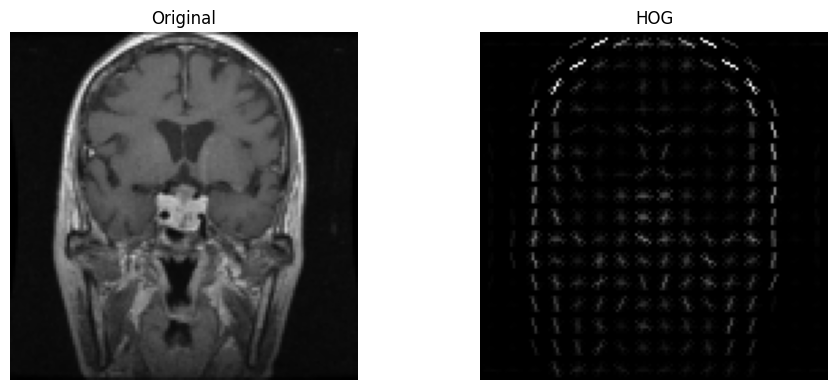

In [15]:
# dzięki temu możemy uchwycić kształty i struktury w obrazie, bo chcemy wykrywać guzy, a guzy mają charakterystyczne kształty i struktury

def extract_hog_features(path: str, visualize: bool = False):
    image = load_and_preprocess_image(path)

    if visualize:
        features, hog_image = hog(
            image,
            **HOG_PARAMS,
            visualize=True,
            feature_vector=True,
        )
        return features, hog_image

    features = hog(
        image,
        **HOG_PARAMS,
        visualize=False,
        feature_vector=True,
    )
    return features

hog_features, hog_image = extract_hog_features(example_path, visualize=True) 
print(hog_features.shape)
#wizualizacja cech HOG
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(example_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
#HOG zwraca nam obraz, który jest wizualizacją cech HOG, ale wartości w tym obrazie mogą być bardzo duże, więc musimy je przeskalować do zakresu [0, 1], żeby móc go poprawnie wyświetlić
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

axes[1].imshow(hog_image, cmap="gray") #wyświetlamy obraz z cechami HOG, ale musimy go przeskalować, żeby był widoczny
axes[1].set_title("HOG")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Budowanie macierzy cech


In [16]:
#funkcja do budowania macierzy cech i wektora etykiet z DataFrame, która iteruje po ścieżkach do obrazów w DataFrame, wyciąga cechy (HOG lub surowe piksele) z każdego obrazu 
# i dodaje je do listy X, a etykiety binarne dodaje do listy y, a następnie zwraca macierz cech X i wektor etykiet y
def build_feature_matrix(df: pd.DataFrame, feature_type: str = "hog"):
    X = []
    y = df["binary_label_value"].to_numpy()

    for path in tqdm(df["image_path"], desc=f"Extracting {feature_type} features"):  #tqdm - to jest biblioteka do tworzenia pasków postępu, desc - to jest opis, który będzie wyświetlany obok paska postępu
        if feature_type == "hog": #sprawdzamy jaki typ cech chcemy wyciągać, jeśli "hog" to wyciągamy cechy HOG, jeśli "raw" to wyciągamy surowe piksele, w przeciwnym razie rzucamy błąd
            features = extract_hog_features(path)
        elif feature_type == "raw":
            features = extract_raw_pixels(path)
        else:
            raise ValueError("feature_type must be 'hog' or 'raw'")
        X.append(features)

    X = np.vstack(X) #vstack - to jest funkcja numpy, która łączy listę tablic w jedną macierz, czyli z listy [array1, array2, ...] robi macierz [[features1], [features2], ...]
    return X, y


X_train_hog, y_train = build_feature_matrix(train_df, feature_type="hog") #budujemy macierz cech i wektor etykiet dla zbioru treningowego, wyciągając cechy HOG z obrazów
X_val_hog, y_val = build_feature_matrix(val_df, feature_type="hog")
X_test_hog, y_test = build_feature_matrix(test_df, feature_type="hog")

print("Training set shape:", X_train_hog.shape, y_train.shape) #sprawdzamy kształt macierzy cech i wektora etykiet dla zbioru treningowego, powinien być (liczba_obrazów, liczba_cech) i (liczba_obrazów,)
print("Validation set shape:", X_val_hog.shape, y_val.shape)
print("Test set shape:", X_test_hog.shape, y_test.shape)

Extracting hog features: 100%|██████████| 1600/1600 [00:22<00:00, 72.65it/s] 

Training set shape: (4480, 8100) (4480,)
Validation set shape: (1120, 8100) (1120,)
Test set shape: (1600, 8100) (1600,)


## podgląd pierwszych 10 obrazów i ich cech HOG

In [17]:
# tworzymy DataFrame z pierwszych 10 wierszy macierzy cech HOG i dodajemy kolumnę z etykietami binarnymi
hog_preview_df = pd.DataFrame(
    X_train_hog[:10, :20],
    columns=[f"hog_{i}" for i in range(20)]
)

hog_preview_df["target"] = y_train[:10]
hog_preview_df

,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,hog_11,hog_12,hog_13,hog_14,hog_15,hog_16,hog_17,hog_18,hog_19,target
0,0.216223,0.027734,0.049397,0.305760,0.305760,0.305760,0.022904,0.059183,0.075626,0.124039,...,0.145683,0.172930,0.305760,0.202459,0.050105,0.200006,0.132754,0.092097,0.049277,1
1,0.037147,0.028303,0.016800,0.152902,0.277062,0.056047,0.032781,0.000000,0.035155,0.049108,...,0.075656,0.086523,0.122339,0.027525,0.032298,0.060343,0.030276,0.063880,0.039758,1
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
3,0.292162,0.166157,0.261905,0.389754,0.389754,0.157887,0.092669,0.000000,0.015966,0.027427,...,0.000000,0.090499,0.389754,0.180389,0.019724,0.000000,0.012366,0.132815,0.046202,1
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.326698,...,0.180370,0.000000,0.146918,0.300163,0.000000,0.000000,0.297128,0.255390,0.063044,0
5,0.443669,0.230876,0.006038,0.143178,0.443669,0.004209,0.000000,0.015926,0.365837,0.028793,...,0.000000,0.002619,0.443669,0.001072,0.000000,0.000000,0.000000,0.443669,0.003956,0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
7,0.227789,0.055439,0.292075,0.290473,0.292075,0.126574,0.240338,0.000000,0.104517,0.216920,...,0.259104,0.011301,0.292075,0.022604,0.181074,0.067022,0.131466,0.103134,0.087599,1
8,0.157042,0.134865,0.019937,0.336150,0.336150,0.149865,0.030681,0.336150,0.336150,0.043623,...,0.044774,0.226923,0.336150,0.012110,0.025429,0.018354,0.064144,0.067945,0.010478,1
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1


##  baseline z DummyClassifier 
- to model konrolny 
- zeby miec punkt odniesienia - jak nasz model osiaga podobny wynik do niego to znaczy, że się nie nauczył nic sensownego


In [18]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=random_state) #most_frequent - ta strategia polega na tym, że model zawsze będzie przewidywał najczęściej występującą klasę w zbiorze treningowym
dummy_clf.fit(X_train_hog, y_train)
y_val_pred_dummy = dummy_clf.predict(X_val_hog)
print("Dummy accuracy:", accuracy_score(y_val, y_val_pred_dummy))
print(classification_report(
    y_val,
    y_val_pred_dummy,
    target_names=["no_tumor", "tumor"],
    zero_division=0, #zero_division=0 - to jest parametr, który określa co zrobić, gdy w klasyfikacji nie ma żadnych przypadków danej klasy, 
    #czyli gdy precision lub recall jest nieokreślone, w takim przypadku ustawiamy je na 0, żeby uniknąć błędów
))

Dummy accuracy: 0.75
              precision    recall  f1-score   support

    no_tumor       0.00      0.00      0.00       280
       tumor       0.75      1.00      0.86       840

    accuracy                           0.75      1120
   macro avg       0.38      0.50      0.43      1120
weighted avg       0.56      0.75      0.64      1120



## Etap 6: modele klasyczne na HOG

## Funkcja evaluate_model
- Funkcja wykonuje cały standardowy proces:
1. trenuje model na danych treningowych,
2. wykonuje predykcję na danych walidacyjnych,
3. oblicza accuracy,
4. wyświetla classification report,
5. pokazuje confusion matrix,
6. zwraca wytrenowany model oraz jego predykcje.

## Confusion matrix

- Confusion matrix pokazuje, ile predykcji było poprawnych i jakie błędy popełnił model.

- Dla tego projektu etykiety oznaczają:
- 0 — no_tumor,
- 1 — tumor.

- Najważniejszy błąd to false negative, czyli sytuacja, w której prawdziwa klasa to tumor, ale model przewidział no_tumor. Taki błąd oznacza, że model nie wykrył guza.

In [19]:
def evaluate_model(name: str, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val) #predykcje modelu na zbiorze walidacyjnym
    print("=" * 80) #drukujemy linię złożoną z 80 znaków "=", żeby oddzielić wyniki poszczególnych modeli i ułatwić czytanie wyników
    print(name) 
    print("Accuracy:", accuracy_score(y_val, y_pred)) #dokładność modelu, czyli stosunek liczby poprawnych predykcji do liczby wszystkich predykcji
    print(classification_report( #raport klasyfikacji, który zawiera precision, recall, f1-score i support dla każdej klasy
        y_val,
        y_pred,
        target_names=["no_tumor", "tumor"],
        zero_division=0,
    ))
    
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1]) 
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["no_tumor", "tumor"],
    )
    disp.plot(values_format="d") #d -format- wartości w macierzy będą wyświetlane jako liczby całkowite

    plt.title(name)
    plt.show()
    return model, y_pred


## pipeline, który składa się z dwóch kroków: 
- skalowania cech za pomocą StandardScaler - zeby wszystkie cechy miały podobną skalę 
- klasyfikacji przy użyciu LogisticRegression
### StandardScaler

StandardScaler standaryzuje cechy według wzoru:

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

gdzie:

- $x$ — wartość cechy,
- $\mu$ — średnia wartość cechy,
- $\sigma$ — odchylenie standardowe cechy.

Przykład dla wartości:

$$
[10,\ 20,\ 30]
$$

Średnia:

$$
\mu = \frac{10 + 20 + 30}{3} = 20
$$

Odchylenie standardowe:

$$
\sigma \approx 8.16
$$

Po standaryzacji:

$$
\frac{10 - 20}{8.16} \approx -1.22
$$

$$
\frac{20 - 20}{8.16} = 0
$$

$$
\frac{30 - 20}{8.16} \approx 1.22
$$

Wynik:

$$
[-1.22,\ 0,\ 1.22]
$$

Dzięki temu cechy mają podobną skalę, co pomaga modelom takim jak Logistic Regression szybciej i stabilniej się uczyć.

Standaryzacja sprawia, że wszystkie cechy mają podobną skalę, co ułatwia i przyspiesza uczenie modeli takich jak Logistic Regression.
- i klasyfikacji za pomocą LogisticRegression, która jest ustawiona na maksymalną liczbę iteracji 5000, zrównoważonymi wagami klas i ustalonym random_state dla powtarzalności wyników



```text
MRI image
    │
    ▼
Preprocessing
(grayscale + resize + normalization)
    │
    ▼
HOG Feature Extraction
    │
    ▼
Feature Vector
    │
    ▼
StandardScaler
    │
    ▼
Logistic Regression
    │
    ▼
Prediction
(tumor / no_tumor)

Logistic Regression + HOG
Accuracy: 0.9821428571428571
              precision    recall  f1-score   support

    no_tumor       0.96      0.96      0.96       280
       tumor       0.99      0.99      0.99       840

    accuracy                           0.98      1120
   macro avg       0.98      0.98      0.98      1120
weighted avg       0.98      0.98      0.98      1120



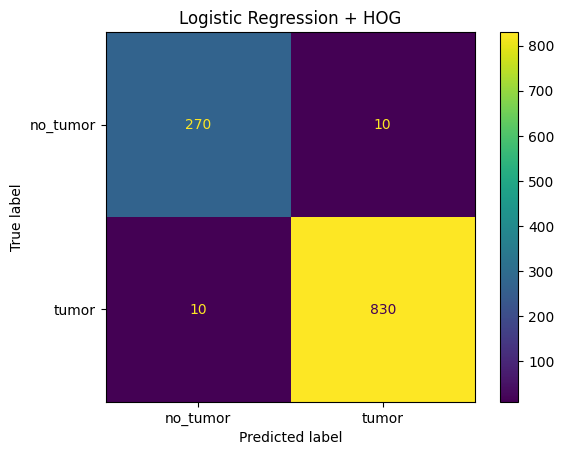

In [20]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=random_state,
    )),
])

logreg_pipeline, y_val_pred_logreg = evaluate_model(
    "Logistic Regression + HOG",
    logreg_pipeline,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)

## Linear SVM 
- próbuje oddzielić klasy jedną prostą granicą

Linear SVM + HOG
Accuracy: 0.975
              precision    recall  f1-score   support

    no_tumor       0.93      0.97      0.95       280
       tumor       0.99      0.98      0.98       840

    accuracy                           0.97      1120
   macro avg       0.96      0.97      0.97      1120
weighted avg       0.98      0.97      0.98      1120



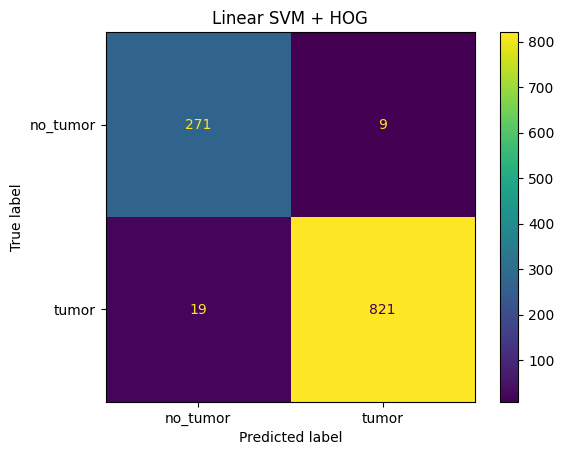

In [21]:
linear_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=10000,
        random_state=random_state,
)),
])
linear_svm_pipeline, y_val_pred_svm = evaluate_model(
    "Linear SVM + HOG",
    linear_svm_pipeline,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)



## RBF SVM
- radial basis function
- tworzy jądro (kernel) który pozwala na tworzenie nieliniowych granic decyzyjnych

RBF SVM + HOG
Accuracy: 0.9767857142857143
              precision    recall  f1-score   support

    no_tumor       0.96      0.95      0.95       280
       tumor       0.98      0.99      0.98       840

    accuracy                           0.98      1120
   macro avg       0.97      0.97      0.97      1120
weighted avg       0.98      0.98      0.98      1120



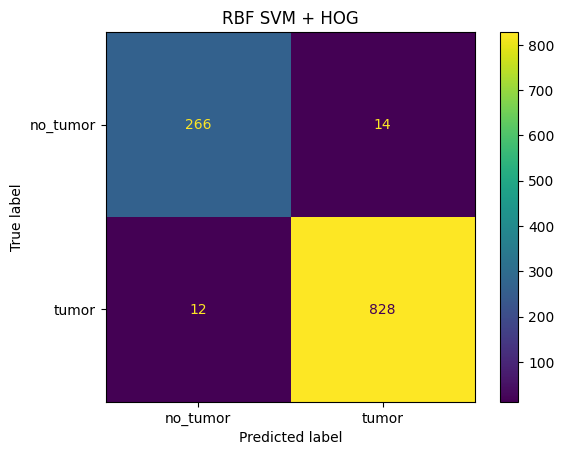

In [22]:
rbf_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=random_state,
)),
])
rbf_svm_pipeline, y_val_pred_rbf = evaluate_model(
    "RBF SVM + HOG",
    rbf_svm_pipeline,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)


# RANDOM FOREST - 

Random Forest + HOG
Accuracy: 0.9651785714285714
              precision    recall  f1-score   support

    no_tumor       0.97      0.89      0.93       280
       tumor       0.96      0.99      0.98       840

    accuracy                           0.97      1120
   macro avg       0.97      0.94      0.95      1120
weighted avg       0.97      0.97      0.96      1120



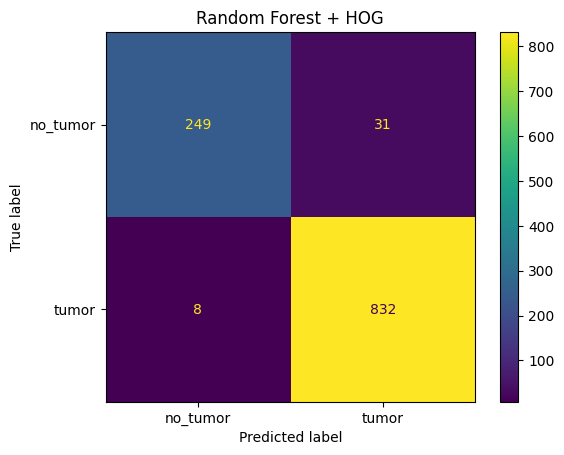

In [23]:
rf_clf = RandomForestClassifier(
    n_estimators=300, #liczba drzew w lesie, im więcej drzew, tym lepsza dokładność, ale też dłuższy czas trenowania
    max_depth=None,
    class_weight="balanced",
    random_state=random_state,
    n_jobs=-1,
)
rf_clf, y_val_pred_rf = evaluate_model(
    "Random Forest + HOG",
    rf_clf,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)


## Bez użycia HOG
- model widzi tylko jasność każdego piksela

Extracting raw features: 100%|██████████| 1120/1120 [00:09<00:00, 113.12it/s]


Logistic Regression + raw pixels
Accuracy: 0.9607142857142857
              precision    recall  f1-score   support

    no_tumor       0.94      0.90      0.92       280
       tumor       0.97      0.98      0.97       840

    accuracy                           0.96      1120
   macro avg       0.95      0.94      0.95      1120
weighted avg       0.96      0.96      0.96      1120



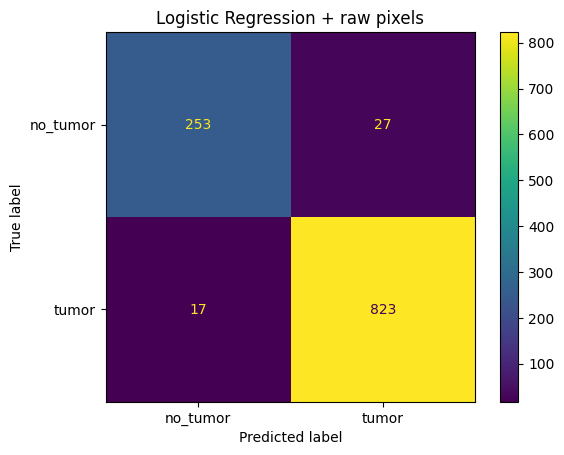

In [24]:
X_train_raw, _ = build_feature_matrix(train_df, feature_type="raw")
X_val_raw, _ = build_feature_matrix(val_df, feature_type="raw")
raw_logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=random_state,
)),
])
raw_logreg_pipeline, y_val_pred_raw = evaluate_model(
    "Logistic Regression + raw pixels",
    raw_logreg_pipeline,
    X_train_raw,
    y_train,
    X_val_raw,
    y_val,
)


## tabela porównująca wszystkie modele

In [25]:
from sklearn.metrics import precision_recall_fscore_support
def get_metrics_row(name: str, feature_type: str, y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1],
        zero_division=0,
)
    return {
        "model": name,
        "features": feature_type,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_tumor": precision[0],
        "recall_tumor": recall[0],
        "f1_tumor": f1[0],
        "support_tumor": support[0],
}
results = []
results.append(get_metrics_row("Dummy", "HOG", y_val, y_val_pred_dummy))
results.append(get_metrics_row("Logistic Regression", "HOG", y_val, y_val_pred_logreg))
results.append(get_metrics_row("Linear SVM", "HOG", y_val, y_val_pred_svm))
results.append(get_metrics_row("RBF SVM", "HOG", y_val, y_val_pred_rbf))
results.append(get_metrics_row("Random Forest", "HOG", y_val, y_val_pred_rf))
results.append(get_metrics_row("Logistic Regression", "raw pixels", y_val, y_val_pred_raw))

results_df = pd.DataFrame(results).sort_values("recall_tumor", ascending=False)
print(results_df)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

results_df.to_csv("outputs/tables/validation_results.csv", index=False)


                 model    features  accuracy  precision_tumor  recall_tumor  \
0                Dummy         HOG  0.750000         0.750000      1.000000   
4        Random Forest         HOG  0.965179         0.964079      0.990476   
1  Logistic Regression         HOG  0.982143         0.988095      0.988095   
3              RBF SVM         HOG  0.976786         0.983373      0.985714   
5  Logistic Regression  raw pixels  0.960714         0.968235      0.979762   
2           Linear SVM         HOG  0.975000         0.989157      0.977381   

   f1_tumor  support_tumor  
0  0.857143            840  
4  0.977099            840  
1  0.988095            840  
3  0.984542            840  
5  0.973964            840  
2  0.983234            840  


## stojenie modelu za pomocą GridSearchCV

In [26]:
param_grid_linear_svm = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
}
linear_svm_for_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=20000,
        random_state=random_state,
    )),
])

grid_linear_svm = GridSearchCV(
    estimator=linear_svm_for_grid,
    param_grid=param_grid_linear_svm,
    scoring="recall", # recall for positive class = tumor
    cv=3,
    n_jobs=1,
    verbose=2,
)
grid_linear_svm.fit(X_train_hog, y_train)

print("Best params:", grid_linear_svm.best_params_)
print("Best CV recall:", grid_linear_svm.best_score_)

best_linear_svm = grid_linear_svm.best_estimator_
y_val_pred_best = best_linear_svm.predict(X_val_hog)

print(classification_report(
y_val,
y_val_pred_best,
target_names=["no_tumor", "tumor"],
zero_division=0,
))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ........................................clf__C=0.01; total time=  15.3s
[CV] END ........................................clf__C=0.01; total time=  10.3s
[CV] END ........................................clf__C=0.01; total time=  10.5s
[CV] END .........................................clf__C=0.1; total time= 1.4min
[CV] END .........................................clf__C=0.1; total time=  38.0s
[CV] END .........................................clf__C=0.1; total time=  47.4s
[CV] END .........................................clf__C=1.0; total time=   8.3s
[CV] END .........................................clf__C=1.0; total time=   4.2s
[CV] END .........................................clf__C=1.0; total time= 1.4min
[CV] END ........................................clf__C=10.0; total time=   3.1s
[CV] END ........................................clf__C=10.0; total time=   2.3s
[CV] END ........................................

In [27]:
param_grid_rbf = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__gamma": ["scale", 0.001, 0.01, 0.1],
}
rbf_for_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=random_state,
    )),
])

grid_rbf = GridSearchCV(
    estimator=rbf_for_grid,
    param_grid=param_grid_rbf,
    scoring="recall",
    cv=3,
    n_jobs=1,
    verbose=2,
)
grid_rbf.fit(X_train_hog, y_train)

print("Best params:", grid_rbf.best_params_)
print("Best CV recall:", grid_rbf.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .......................clf__C=0.1, clf__gamma=scale; total time=  23.0s
[CV] END .......................clf__C=0.1, clf__gamma=scale; total time=  23.2s
[CV] END .......................clf__C=0.1, clf__gamma=scale; total time=  22.4s
[CV] END .......................clf__C=0.1, clf__gamma=0.001; total time=  41.6s
[CV] END .......................clf__C=0.1, clf__gamma=0.001; total time=  41.8s
[CV] END .......................clf__C=0.1, clf__gamma=0.001; total time=  42.2s
[CV] END ........................clf__C=0.1, clf__gamma=0.01; total time=  42.5s
[CV] END ........................clf__C=0.1, clf__gamma=0.01; total time=  42.4s
[CV] END ........................clf__C=0.1, clf__gamma=0.01; total time=  41.2s
[CV] END .........................clf__C=0.1, clf__gamma=0.1; total time=  42.7s
[CV] END .........................clf__C=0.1, clf__gamma=0.1; total time=  41.5s
[CV] END .........................clf__C=0.1, cl

## Ocena najlepszego modelu na zbiorze testowym
## Macierz pomyłek

Final test accuracy: 0.93875
              precision    recall  f1-score   support

    no_tumor       0.80      1.00      0.89       400
       tumor       1.00      0.92      0.96      1200

    accuracy                           0.94      1600
   macro avg       0.90      0.96      0.92      1600
weighted avg       0.95      0.94      0.94      1600



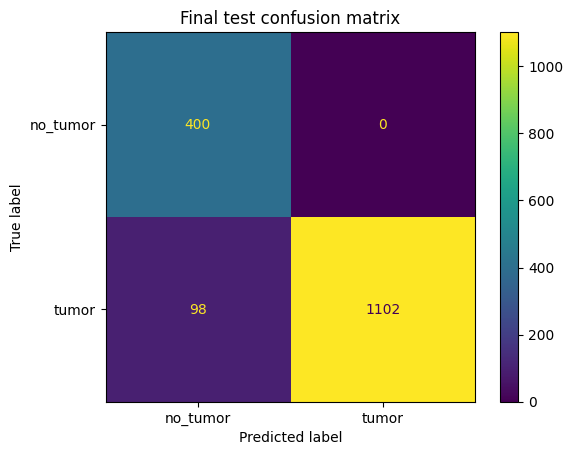

{'TN': np.int64(400), 'FP': np.int64(0), 'FN': np.int64(98), 'TP': np.int64(1102)}


In [28]:
best_model = best_linear_svm # or another selected model
y_test_pred = best_model.predict(X_test_hog)
print("Final test accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["no_tumor", "tumor"],
    zero_division=0,
))
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no_tumor", "tumor"],
)
disp.plot(values_format="d")
plt.title("Final test confusion matrix")
plt.show()
# Optional: exact TN, FP, FN, TP values.
tn, fp, fn, tp = cm.ravel()
print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

## Analiza błedów

In [29]:
test_analysis_df = test_df.copy().reset_index(drop=True)
test_analysis_df["y_true"] = y_test
test_analysis_df["y_pred"] = y_test_pred

def error_type(row):
    if row["y_true"] == 1 and row["y_pred"] == 0:
        return "false_negative"
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "false_positive"
    return "correct"
test_analysis_df["error_type"] = test_analysis_df.apply(error_type, axis=1)

print(test_analysis_df["error_type"].value_counts())

error_type
correct           1502
false_negative      98
Name: count, dtype: int64


## Wizualizacja false negative

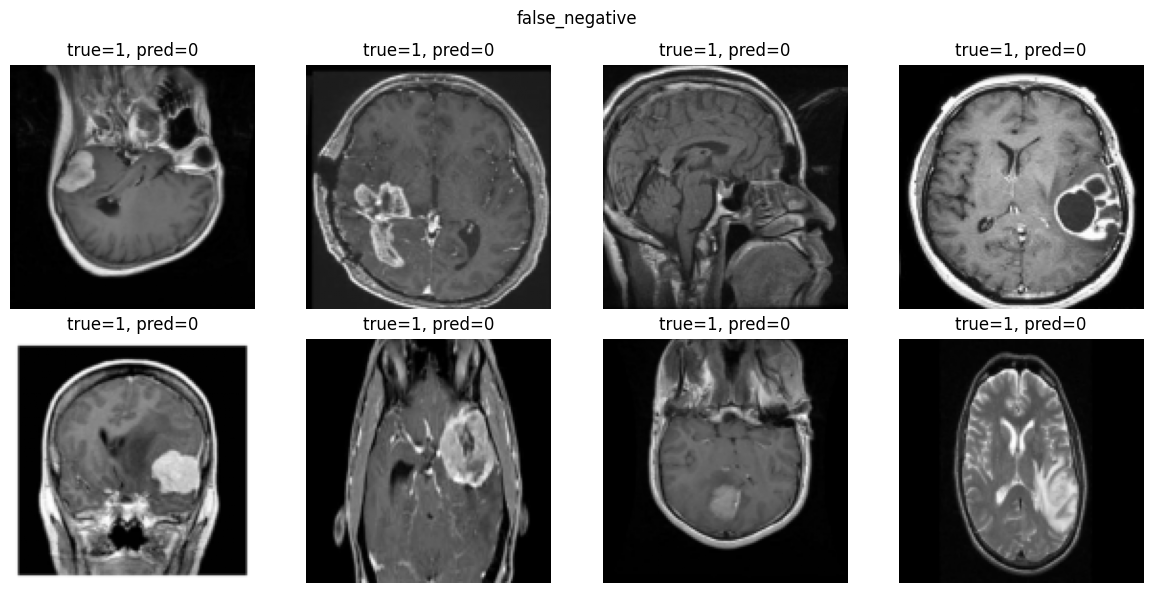

No examples for false_positive


In [31]:
def show_error_examples(df: pd.DataFrame, error_name: str, n: int = 8):
    subset = df[df["error_type"] == error_name]
    if subset.empty:
        print(f"No examples for {error_name}")
        return
    
    sample = subset.sample(n=min(n, len(subset)), random_state=random_state)

    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(12, 3 * rows))

    for i, (_, row) in enumerate(sample.iterrows(), start=1):
        image = load_and_preprocess_image(row["image_path"])
        plt.subplot(rows, cols, i)
        plt.imshow(image, cmap="gray")
        plt.title(f"true={row['y_true']}, pred={row['y_pred']}")
        plt.axis("off")

    plt.suptitle(error_name)
    plt.tight_layout()
    plt.show()

show_error_examples(test_analysis_df, "false_negative", n=8)
show_error_examples(test_analysis_df, "false_positive", n=8)
